#Laboratorio: Comportamiento del Perceptrón Simple
En este entorno, exploraremos cómo la función de activación, la tasa de aprendizaje y la regularización afectan la convergencia y la capacidad de generalización de un modelo lineal.

## Configuración del Entorno y Librerías

Primero, importamos las herramientas necesarias. Utilizaremos NumPy para el cálculo matricial y Matplotlib para visualizar las fronteras de decisión.

In [ ]:
import numpy as np # Procesamiento numérico y álgebra lineal
import matplotlib.pyplot as plt # Visualización de datos y gráficos
from sklearn.datasets import make_blobs # Generación de datos sintéticos

# Configuración estética para los gráficos
plt.style.use('ggplot')

## Definición de Funciones de Activación

Como vimos en la teoría, la función de activación introduce la no linealidad o el criterio de decisión. Implementaremos las más comunes para comparar su respuesta.

In [ ]:
def step_function(z):
    return np.where(z >= 0, 1, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z >= 0, z, alpha * z)

Explicación del bloque: Estas funciones toman el valor $Z$ (la suma ponderada) y lo transforman. La función step es binaria, mientras que sigmoid devuelve una probabilidad y relu gestiona la activación rectificada.

## El Modelo: Perceptrón con Regularización

Construiremos una clase que represente al Perceptrón. He integrado los términos de L1 y L2 en la regla de actualización para observar su impacto en los pesos.

In [ ]:
class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=100, activation='step', reg=None, lam=0.01):
        # Inicialización de pesos y sesgo de forma aleatoria
        self.w = np.random.randn(input_size)
        self.b = np.random.randn()
        self.lr = lr # Tasa de aprendizaje
        self.epochs = epochs # Iteraciones sobre el dataset
        self.activation_name = activation
        self.reg = reg # Tipo de regularización: 'L1', 'L2' o None
        self.lam = lam # Coeficiente lambda para regularización
        self.history = [] # Para rastrear la pérdida

    def _activate(self, z):
        if self.activation_name == 'step': return step_function(z)
        if self.activation_name == 'sigmoid': return sigmoid(z)
        if self.activation_name == 'relu': return relu(z)
        return step_function(z)

    def predict(self, x):
        z = np.dot(x, self.w) + self.b
        return self._activate(z)

    def train(self, x, y):
        for epoch in range(self.epochs):
            total_error = 0
            for i in range(len(x)):
                # 1. Forward Pass
                prediction = self.predict(x[i])
                error = y[i] - prediction
                total_error += error**2

                # 2. Cálculo de la penalización (Regularización)
                reg_term_w = 0
                if self.reg == 'L1':
                    reg_term_w = self.lam * np.sign(self.w)
                elif self.reg == 'L2':
                    reg_term_w = self.lam * 2 * self.w

                # 3. Regla de actualización (Gradiente con Regularización)
                self.w += self.lr * (error * x[i] - reg_term_w)
                self.b += self.lr * error

            self.history.append(total_error / len(x))

Explicación del bloque: En la regla de actualización, el término reg_term_w resta importancia a los pesos en cada paso. L1 usa el signo del peso (presión constante hacia cero), mientras que L2 usa el valor del peso (presión proporcional).

## Generación de Datos Sintéticos
Para que el Perceptrón simple funcione, los datos deben ser linealmente separables.

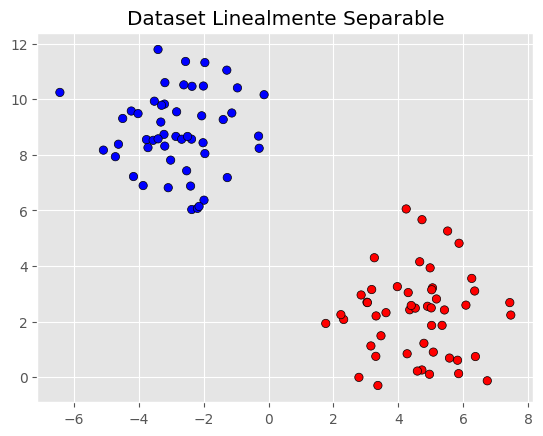

In [ ]:
# Generamos 100 puntos en 2 dimensiones divididos en 2 clases
x_train, y_train = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=1.5, random_state=42)

# Graficamos los datos originales
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap='bwr', edgecolors='k')
plt.title("Dataset Linealmente Separable")
plt.show()

## Experimentación: Tasa de Aprendizaje y Regularización
A continuación, entrenaremos tres modelos con diferentes configuraciones para comparar sus curvas de aprendizaje y fronteras de decisión.

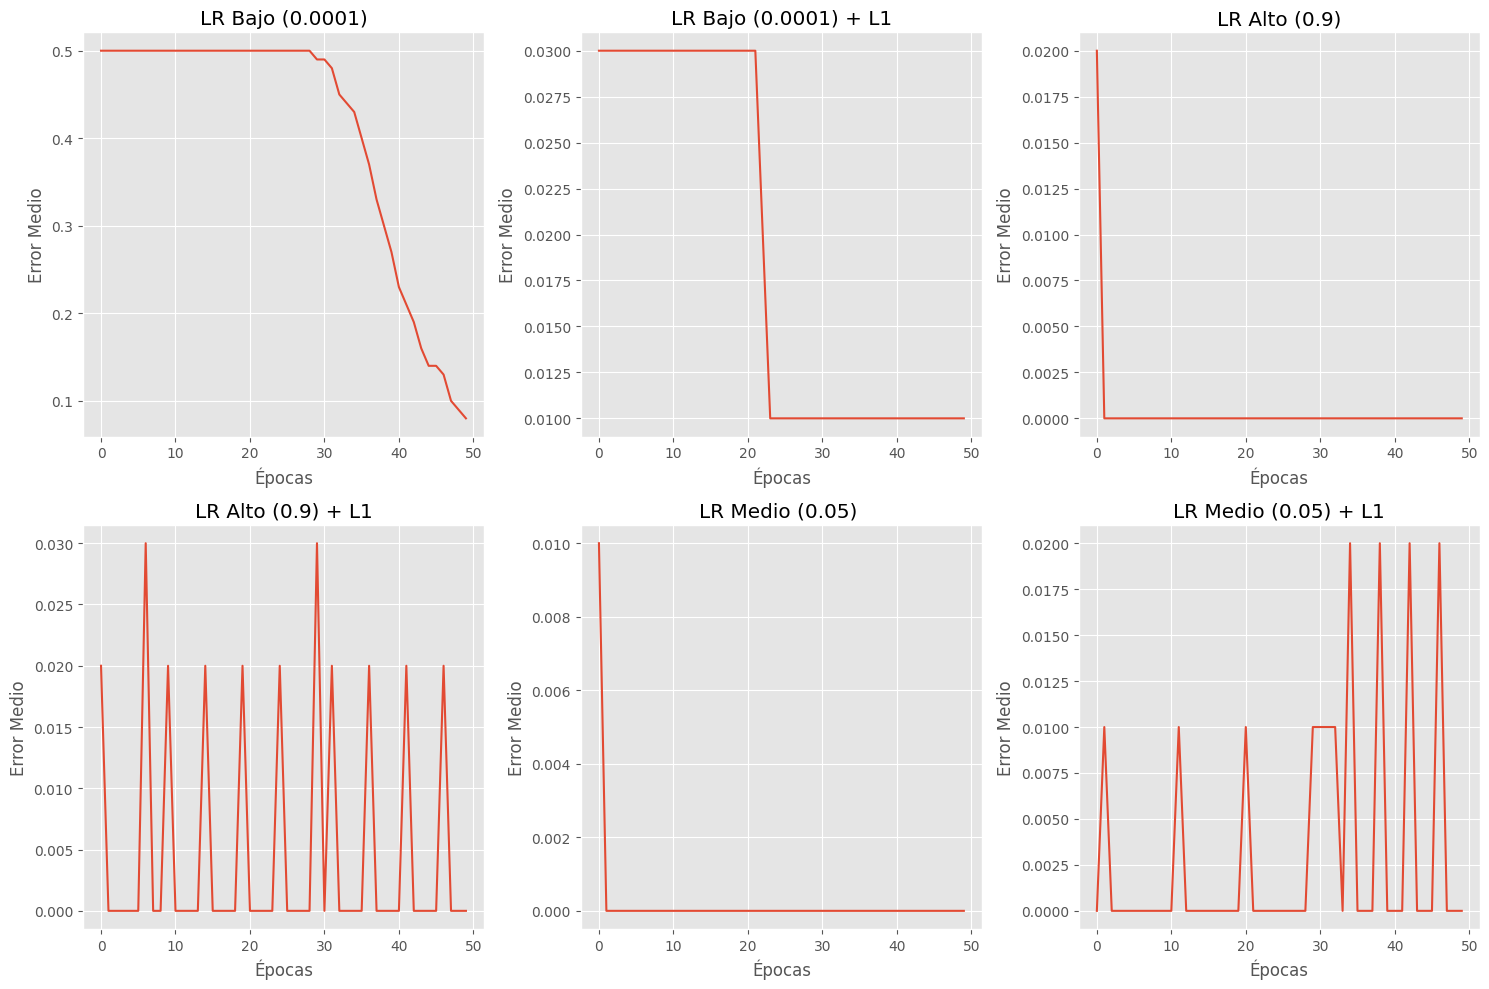

In [ ]:
# CONFIGURACIONES A PROBAR
configs = [
    {'lr': 0.0001, 'reg': None, 'label': 'LR Bajo (0.0001)'},
    {'lr': 0.0001, 'reg': 'L1', 'label': 'LR Bajo (0.0001) + L1'},
    {'lr': 0.9,   'reg': None, 'label': 'LR Alto (0.9)'},
    {'lr': 0.9,   'reg': 'L1', 'label': 'LR Alto (0.9) + L1'},
    {'lr': 0.05,   'reg': None, 'label': 'LR Medio (0.05) '},
    {'lr': 0.05,   'reg': 'L1', 'label': 'LR Medio (0.05) + L1'}
]

plt.figure(figsize=(15, 10))

for i, conf in enumerate(configs):
    model = Perceptron(input_size=2, lr=conf['lr'], reg=conf['reg'], epochs=50)
    model.train(x_train, y_train)

    plt.subplot(2, 3, i+1) # Changed from 1,3 to 2,3 to accommodate all 6 plots
    plt.plot(model.history)
    plt.title(conf['label'])
    plt.xlabel("Épocas")
    plt.ylabel("Error Medio")

plt.tight_layout()
plt.show()

Guía para el análisis:

* LR Bajo: Verán una curva que desciende muy lento. Es estable pero ineficiente.

* LR Alto: Es probable que la curva oscile o "rebote" antes de estabilizarse.

* Reg L1: Si imprimen los pesos finales (model.w), verán que los valores son mucho más pequeños o nulos comparados con los modelos sin regularización.

## Visualización de la Frontera de Decisión
Finalmente, creamos una función para ver cómo el Perceptrón "dibuja" la línea que separa las clases.

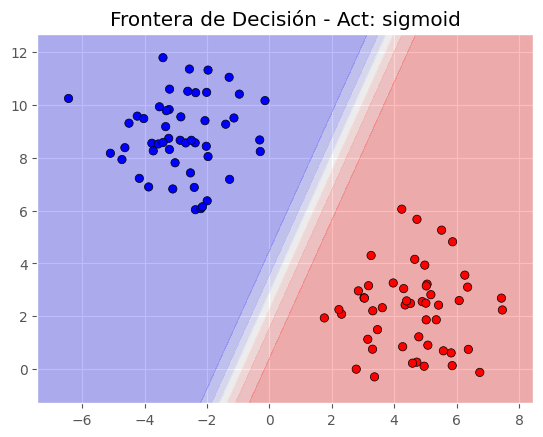

In [ ]:
def plot_decision_boundary(model, x, y):
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = np.array([model.predict(p) for p in grid]).reshape(xx.shape)

    plt.contourf(xx, yy, probs, alpha=0.3, cmap='bwr')
    plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.title(f"Frontera de Decisión - Act: {model.activation_name}")

# Ejemplo de uso:
modelo_final = Perceptron(input_size=2, lr=0.1, activation='sigmoid', epochs=100)
modelo_final.train(x_train, y_train)
plot_decision_boundary(modelo_final, x_train, y_train)

## Propuesta:
* Cambien el cluster_std a 4.0 en el bloque de datos para que las clases se mezclen. Observen cómo el Perceptrón nunca llega a error cero (problema de no separabilidad lineal).

* Comparen L1 vs L2: Impriman los pesos finales con print(modelo.w). ¿Cuál técnica deja pesos más cercanos a cero absoluto?

* Funciones de Activación: Cambien entre step y sigmoid. Noten cómo la frontera de decisión es idéntica pero la "suavidad" de la transición (si usáramos un mapa de calor) cambiaría.

# Laboratorio: Modelado de Sistemas con TensorFlow
En este cuaderno aprenderemos a construir un Perceptrón Simple utilizando la API de alto nivel de Keras, explorando el impacto de los hiperparámetros en el entrenamiento.

## Instalación e Importación de Librerías
En Colab, TensorFlow ya viene preinstalado. Utilizaremos el módulo layers para definir la neurona y optimizers para gestionar la tasa de aprendizaje.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Comprobamos la versión de TF
print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.19.0


## Preparación de Datos y Preprocesamiento
En el modelado con redes neuronales, es una buena práctica escalar los datos para que el motor de optimización trabaje en un rango numérico estable.

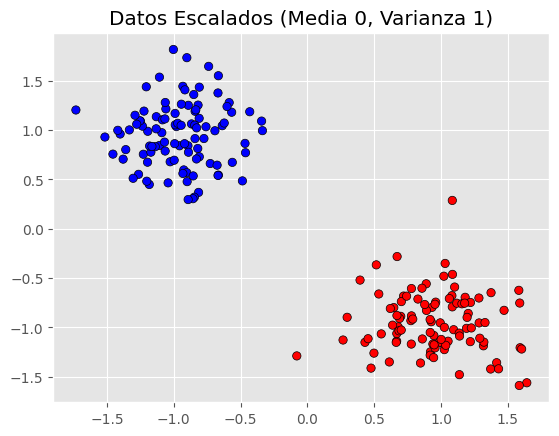

In [ ]:
# Generamos datos linealmente separables
x_train, y_train = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=1.2, random_state=42)

# Escalado de datos: Restamos la media y dividimos por la desviación estándar
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='bwr', edgecolors='k')
plt.title("Datos Escalados (Media 0, Varianza 1)")
plt.show()

## Construcción del Modelo con Capas y Regularización
En TensorFlow, un Perceptrón simple es una red Sequential con una sola capa Dense de 1 unidad.

In [ ]:
def create_perceptron(activation='sigmoid', learning_rate=0.01, l1=0.0, l2=0.0):
    # Definimos la arquitectura
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            units=1,
            input_shape=(2,),
            activation=activation,
            # Aplicamos regularización al núcleo (los pesos W)
            kernel_regularizer=tf.keras.regularizers.L1L2(l1=l1, l2=l2)
        )
    ])

    # Configuramos el optimizador (Descenso de Gradiente Estocástico)
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    # Compilamos el modelo indicando la función de pérdida (Binary Crossentropy para clasificación)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

Explicación del bloque: Aquí units=1 indica que tenemos una sola neurona. El parámetro kernel_regularizer es el que aplica las penalizaciones L1 y L2 directamente sobre la función de costo durante el entrenamiento.

## Experimentación con la Tasa de Aprendizaje
Vamos a comparar cómo influye el Learning Rate en la velocidad de convergencia del error (loss).

Entrenando con LR: 0.001...
Entrenando con LR: 0.05...
Entrenando con LR: 1.0...


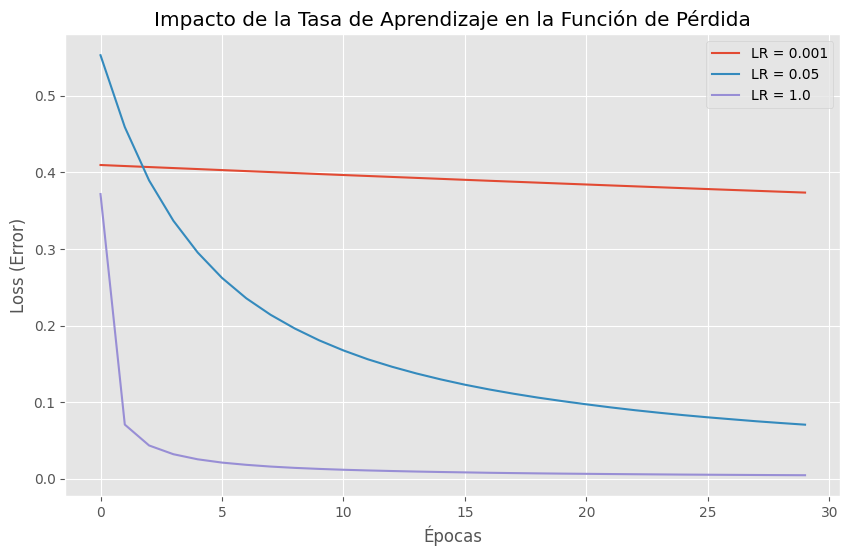

In [ ]:
rates = [0.001, 0.05, 1.0]
histories = {}

for lr in rates:
    print(f"Entrenando con LR: {lr}...")
    model = create_perceptron(learning_rate=lr)
    history = model.fit(x_train, y_train, epochs=30, verbose=0)
    histories[lr] = history.history['loss']

# Graficamos la pérdida
plt.figure(figsize=(10, 6))
for lr, loss in histories.items():
    plt.plot(loss, label=f'LR = {lr}')
plt.title("Impacto de la Tasa de Aprendizaje en la Función de Pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss (Error)")
plt.legend()
plt.show()

Análisis: Si el LR es 1.0, verás que el error cae muy rápido pero puede volverse inestable. Si es 0.001, la caída es casi imperceptible en pocas épocas.

## Visualización de la Frontera de Decisión
Para modelos de TensorFlow, necesitamos usar los métodos de predicción internos para generar el mapa de calor de las categorías.

1513/1513 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


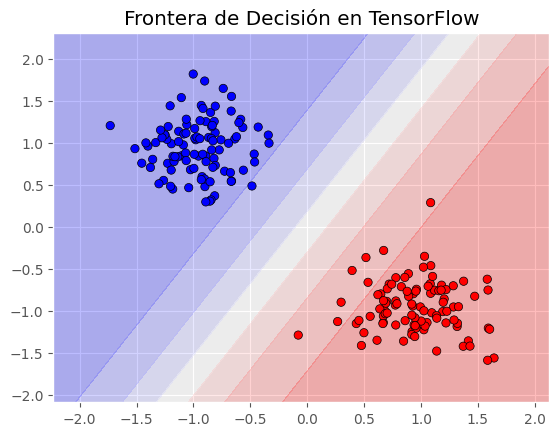

In [ ]:
def plot_tf_decision_boundary(model, x, y):
    x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
    y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # Predecimos sobre toda la cuadrícula
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.title(f"Frontera de Decisión en TensorFlow")

# Entrenamos un modelo final con regularización L2 para suavizar la frontera
final_model = create_perceptron(activation='sigmoid', learning_rate=0.1, l2=0.01)
final_model.fit(x_train, y_train, epochs=50, verbose=0)

plot_tf_decision_boundary(final_model, x_train, y_train)

## Propuesta:
* Exploración de Pesos: Una vez entrenado el modelo con L1, ejecuta final_model.get_weights(). Observa si algún peso es exactamente 0.0 (o muy cercano).

* Cambio de Función: Modifica la función de activación a tanh o relu. Recuerda que para clasificación binaria la salida debe estar entre 0 y 1, por lo que relu podría requerir un ajuste en la función de pérdida.

* No Linealidad: Intenta usar este mismo código para resolver un dataset tipo XOR (puedes generarlo con np.logical_xor). Verás que el Perceptrón de una sola capa de TensorFlow, por más potente que sea la librería, no podrá resolverlo, demostrando la necesidad de capas ocultas.